In [ ]:
import pandas as pd
import seaborn as sns
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

In [167]:
def data_preprocessing_pipeline(dataset_path, max_size=100000, save=False, save_path='dataset.tsv'): 
    with open(dataset_path, "r", encoding='UTF-8') as file:
        try:
            ds_json = json.load(file)
        except:
            try:
                ds_json = []
                size = 0
                for line in tqdm(file, desc='Загрузка данных'):
                    ds_json.append(json.loads(line))
                    size += 1
                    if size >= max_size:
                        break
            except:
                raise RuntimeError('File format is not json or jsonl')
    
    df_origin = pd.DataFrame(columns = ['origin_idx', 'arxiv_id', 'title', 'abstract'])
    
    origin_idx = 0
    for art in tqdm(ds_json, 'Создание pandas-DataFrame из данных'):
        if 'summary' in art: 
            arxiv_id = art['id']
            title = art['title']
            abstract = art['summary']
            row = pd.DataFrame({
                'origin_idx' : origin_idx,
                'arxic_id' : [id],
                'title' : [title],
                'abstract' : [abstract]
            })
            df_origin = pd.concat([df_origin, row], ignore_index=True)         
        origin_idx += 1

    df_clean = df_origin.copy()    

    print('Нормализация названий: ', end='')    
    df_clean['title'] = df_origin['title'].fillna('').str.replace(r'[\n\t]', ' ')
    df_clean['title'] = df_origin['title'].str.replace(r'\s+', ' ')
    print('выполнено.')

    print('Нормализация абстрактов: ', end='')  
    df_clean['abstract'] = df_origin['abstract'].fillna('').str.replace(r'[\n\t]', ' ')
    df_clean['abstract'] = df_origin['abstract'].str.replace(r'\s+', ' ')
    print('выполнено.')

    print('Сбор статистики размера абстрактов: ', end='')
    df_clean['words_num'] = df_clean['abstract'].str.count(' ') + 1
    df_clean['sents_num'] = df_clean['abstract'].str.count(r'[.!?]+ ') + 1 
    print('выполнено.')

    df_good = df_clean.copy()

    print('Формирование итоговой выборки: ', end='')
    df_good = df_good[df_good['words_num'] >= 50]
    df_good = df_good[df_good['words_num'] <= 250]
    df_good = df_good[df_good['sents_num'] <= 12]
    print('выполнено.')

    if save:
        print('Сохранение датасета: ', end='')
        df_good.to_csv(save_path, sep='\t', encoding='utf-8-sig')
        print('выполнено.')

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    ax_lu, ax_ru, ax_ld, ax_rd = axes.flatten()

    ax_lu.set_title('Распределение длин слов в абстракте в оригинале')
    sns.histplot(df_clean['words_num'], ax=ax_lu, kde=True)
    ax_ru.set_title('Распределение количества предложений в абстракте в оригинале')
    sns.histplot(df_clean['sents_num'], ax=ax_ru)
    ax_ld.set_title('Распределение длин слов в абстракте в итоге')
    sns.histplot(df_good['words_num'], ax=ax_ld, kde=True)
    ax_rd.set_title('Распределение количества предложений в абстракте в итоге')
    sns.histplot(df_good['sents_num'], ax=ax_rd)
    
    plt.tight_layout()
    plt.show()

    return df_good

Создание pandas-DataFrame из данных: 100%|██████████| 41000/41000 [00:47<00:00, 859.86it/s] 


Нормализация названий: выполнено.
Нормализация абстрактов: выполнено.
Сбор статистики размера абстрактов: выполнено.
Формирование итоговой выборки: выполнено.
Сохранение датасета: выполнено.


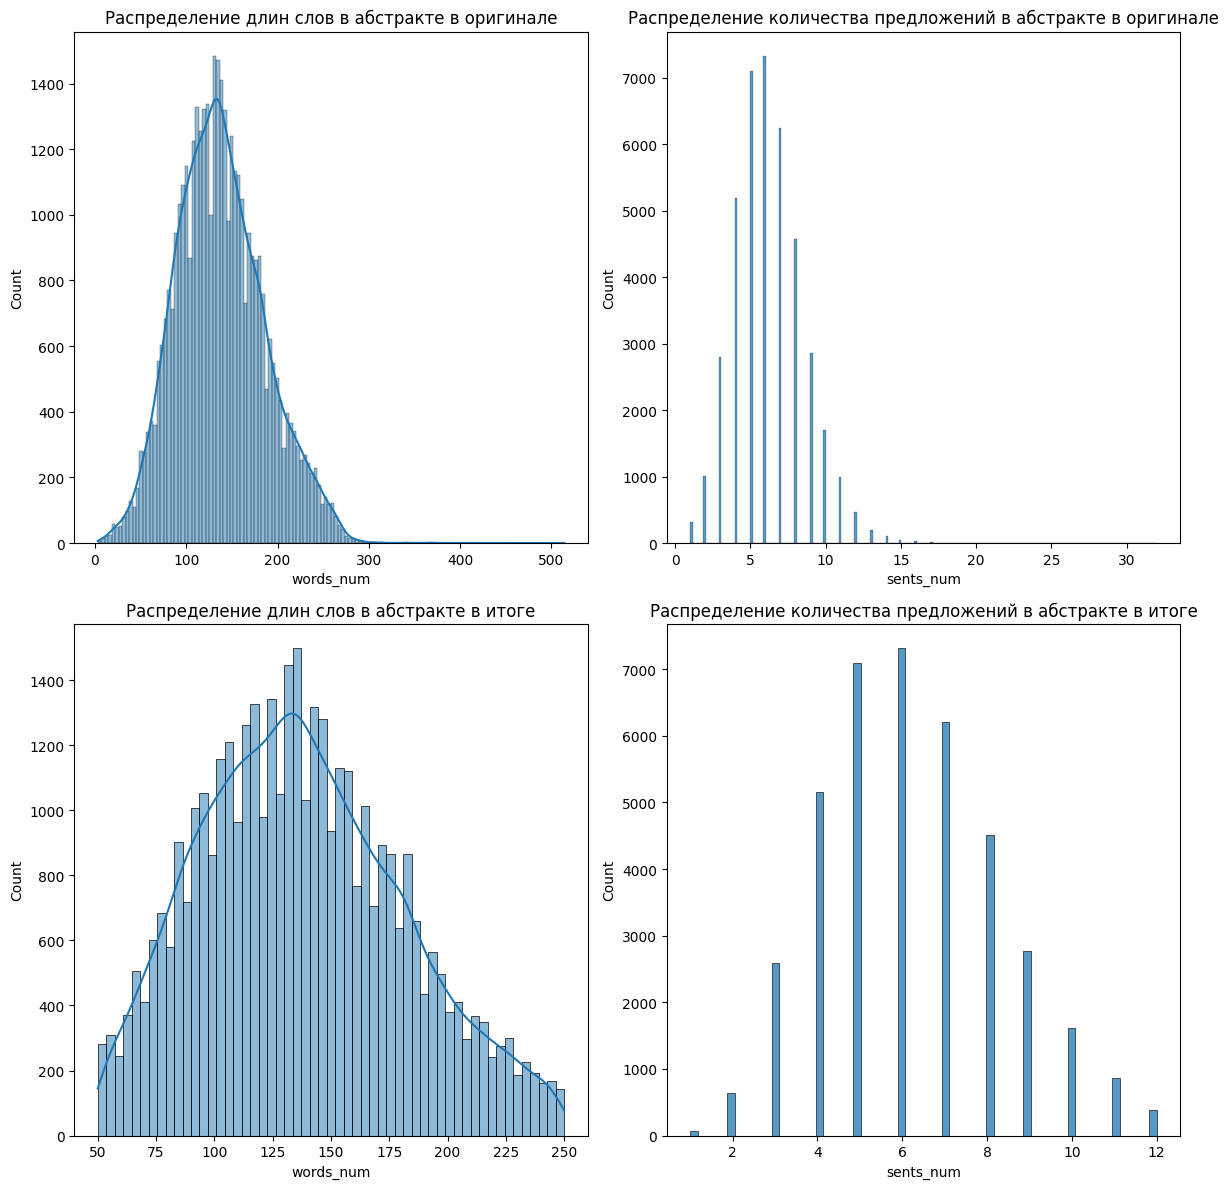

,origin_idx,arxiv_id,title,abstract,arxic_id,words_num,sents_num
0,0,NaN,Dual Recurrent Attention Units for Visual Ques...,We propose an architecture for VQA which utili...,1407.0380v1,100,5
1,1,NaN,Sequential Short-Text Classification with Recu...,Recent approaches based on artificial neural n...,1407.0380v1,77,4
2,2,NaN,Multiresolution Recurrent Neural Networks: An ...,We introduce the multiresolution recurrent neu...,1407.0380v1,183,8
3,3,NaN,Learning what to share between loosely related...,Multi-task learning is motivated by the observ...,1407.0380v1,159,8
4,4,NaN,A Deep Reinforcement Learning Chatbot,We present MILABOT: a deep reinforcement learn...,1407.0380v1,118,6
...,...,...,...,...,...,...,...
40995,40995,NaN,Nearly Tight Bounds on $\ell_1$ Approximation ...,We study the complexity of learning and approx...,1407.0380v1,223,10
40996,40996,NaN,Concurrent bandits and cognitive radio networks,We consider the problem of multiple users targ...,1407.0380v1,99,5
40997,40997,NaN,A Comparison of Clustering and Missing Data Me...,"In this paper, we compare and analyze clusteri...",1407.0380v1,96,4
40998,40998,NaN,Applying machine learning to the problem of ch...,Cylindrical algebraic decomposition(CAD) is a ...,1407.0380v1,89,5


In [168]:
data_preprocessing_pipeline('../origins/41Kmeta_en/arxivData.json', save=True, save_path='../dataset/clean.tsv')

***Далее &mdash; блоки-артефакты разработки пайплайна.***

In [3]:
with open("../origins/41Kmeta_en/arxivData.json", "r", encoding='UTF-8') as file:
    ds_json = json.load(file)
ds_json[0], len(ds_json)

({'author': "[{'name': 'Ahmed Osman'}, {'name': 'Wojciech Samek'}]",
  'day': 1,
  'id': '1802.00209v1',
  'link': "[{'rel': 'alternate', 'href': 'http://arxiv.org/abs/1802.00209v1', 'type': 'text/html'}, {'rel': 'related', 'href': 'http://arxiv.org/pdf/1802.00209v1', 'type': 'application/pdf', 'title': 'pdf'}]",
  'month': 2,
  'summary': 'We propose an architecture for VQA which utilizes recurrent layers to\ngenerate visual and textual attention. The memory characteristic of the\nproposed recurrent attention units offers a rich joint embedding of visual and\ntextual features and enables the model to reason relations between several\nparts of the image and question. Our single model outperforms the first place\nwinner on the VQA 1.0 dataset, performs within margin to the current\nstate-of-the-art ensemble model. We also experiment with replacing attention\nmechanisms in other state-of-the-art models with our implementation and show\nincreased accuracy. In both cases, our recurrent att

In [ ]:
df_origin = pd.DataFrame(columns = ['origin_idx', 'id', 'title', 'abstract'])
origin_idx = 0
for art in tqdm(ds_json):
    if 'summary' in art: 
        id = art['id']
        title = art['title']
        abstract = art['summary']
        row = pd.DataFrame({
            'origin_idx' : origin_idx,
            'id' : [id],
            'title' : [title],
            'abstract' : [abstract]
        })
        df_origin = pd.concat([df_origin, row], ignore_index=True)         
    origin_idx += 1
df_origin.head(5)

  0%|          | 0/41000 [00:00<?, ?it/s]

100%|██████████| 41000/41000 [00:45<00:00, 895.17it/s] 


,origin_idx,id,title,abstract
0,0,1802.00209v1,Dual Recurrent Attention Units for Visual Ques...,We propose an architecture for VQA which utili...
1,1,1603.03827v1,Sequential Short-Text Classification with Recu...,Recent approaches based on artificial neural n...
2,2,1606.00776v2,Multiresolution Recurrent Neural Networks: An ...,We introduce the multiresolution recurrent neu...
3,3,1705.08142v2,Learning what to share between loosely related...,Multi-task learning is motivated by the observ...
4,4,1709.02349v2,A Deep Reinforcement Learning Chatbot,We present MILABOT: a deep reinforcement learn...


In [ ]:
df_origin['abs_len'] = df_origin['abstract'].str.len()

<Axes: xlabel='abs_len', ylabel='Count'>

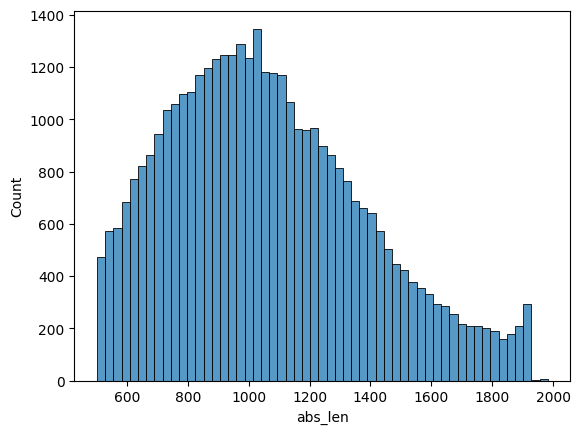

In [ ]:
df_good = df_origin[(df_origin['abs_len'] > 500) & (df_origin['abs_len'] < 2000)]
sns.histplot(df_good['abs_len'])

In [33]:
df_good.min()

origin_idx                                                    0
id                                                  0704.1020v1
title         "Attention" for Detecting Unreliable News in t...
abstract      "Background subtraction" is an old technique f...
abs_len                                                     501
dtype: object

In [34]:
df_good[df_good['abs_len'] == 501]

,origin_idx,id,title,abstract,abs_len
6642,6642,1704.06656v1,Feature selection algorithm based on Catastrop...,In this paper we introduce a new feature selec...,501
8766,8766,cs/0103002v1,Quantitative Neural Network Model of the Tip-o...,A new three-stage computer artificial neural n...,501
10428,10428,1308.4214v1,Pylearn2: a machine learning research library,Pylearn2 is a machine learning research librar...,501
11985,11985,1705.09869v2,Dimensionality reduction for acoustic vehicle ...,We propose a method for recognizing moving veh...,501
13362,13362,1103.2741v1,Memory Retrieval in the B-Matrix Neural Network,This paper is an extension to the memory retri...,501
17297,17297,1710.01411v1,Transferring Semantic Roles Using Translation ...,Our paper addresses the problem of annotation ...,501
20154,20154,1411.7480v1,Unweighted Stochastic Local Search can be Effe...,"We present ULSA, a novel stochastic local sear...",501
24912,24912,1412.7851v1,Fractal descriptors based on the probability d...,"In this work, we propose a novel technique for...",501
32048,32048,1406.3726v1,Evaluation of Machine Learning Techniques for ...,We evaluate the following Machine Learning tec...,501
32058,32058,1406.6176v1,Composite Likelihood Estimation for Restricted...,Learning the parameters of graphical models us...,501


In [35]:
df_good.loc[6642]['abstract']

'In this paper we introduce a new feature selection algorithm to remove the\nirrelevant or redundant features in the data sets. In this algorithm the\nimportance of a feature is based on its fitting to the Catastrophe model.\nAkaike information crite- rion value is used for ranking the features in the\ndata set. The proposed algorithm is compared with well-known RELIEF feature\nselection algorithm. Breast Cancer, Parkinson Telemonitoring data and Slice\nlocality data sets are used to evaluate the model.'

In [ ]:
df_origin.drop('good', axis=1, inplace=True)
df_origin.drop('abs_len', axis=1, inplace=True)

In [ ]:
df_origin.head()

,origin_idx,id,title,abstract
0,0,1802.00209v1,Dual Recurrent Attention Units for Visual Ques...,We propose an architecture for VQA which utili...
1,1,1603.03827v1,Sequential Short-Text Classification with Recu...,Recent approaches based on artificial neural n...
2,2,1606.00776v2,Multiresolution Recurrent Neural Networks: An ...,We introduce the multiresolution recurrent neu...
3,3,1705.08142v2,Learning what to share between loosely related...,Multi-task learning is motivated by the observ...
4,4,1709.02349v2,A Deep Reinforcement Learning Chatbot,We present MILABOT: a deep reinforcement learn...


In [ ]:
df_origin['abstract_clean'] = df_origin['abstract'].fillna('').str.replace('\n', ' ', regex=False)
df_origin['word_num'] = df_origin['abstract_clean'].str.count(' ') + 1
df_origin['sents_num'] = df_origin['abstract_clean'].str.count(r'[.!?]+ ') + 1

In [ ]:
df_origin

,origin_idx,id,title,abstract,abstract_clean,word_num,sents_num
0,0,1802.00209v1,Dual Recurrent Attention Units for Visual Ques...,We propose an architecture for VQA which utili...,We propose an architecture for VQA which utili...,110,5
1,1,1603.03827v1,Sequential Short-Text Classification with Recu...,Recent approaches based on artificial neural n...,Recent approaches based on artificial neural n...,84,4
2,2,1606.00776v2,Multiresolution Recurrent Neural Networks: An ...,We introduce the multiresolution recurrent neu...,We introduce the multiresolution recurrent neu...,201,9
3,3,1705.08142v2,Learning what to share between loosely related...,Multi-task learning is motivated by the observ...,Multi-task learning is motivated by the observ...,174,8
4,4,1709.02349v2,A Deep Reinforcement Learning Chatbot,We present MILABOT: a deep reinforcement learn...,We present MILABOT: a deep reinforcement learn...,129,6
...,...,...,...,...,...,...,...
40995,40995,1404.4702v2,Nearly Tight Bounds on $\ell_1$ Approximation ...,We study the complexity of learning and approx...,We study the complexity of learning and approx...,247,13
40996,40996,1404.5421v1,Concurrent bandits and cognitive radio networks,We consider the problem of multiple users targ...,We consider the problem of multiple users targ...,108,6
40997,40997,1404.5899v1,A Comparison of Clustering and Missing Data Me...,"In this paper, we compare and analyze clusteri...","In this paper, we compare and analyze clusteri...",105,4
40998,40998,1404.6369v1,Applying machine learning to the problem of ch...,Cylindrical algebraic decomposition(CAD) is a ...,Cylindrical algebraic decomposition(CAD) is a ...,97,5


In [ ]:
(df_origin.loc[0]['abstract'],
df_origin.loc[0]['abstract_clean'])

('We propose an architecture for VQA which utilizes recurrent layers to\ngenerate visual and textual attention. The memory characteristic of the\nproposed recurrent attention units offers a rich joint embedding of visual and\ntextual features and enables the model to reason relations between several\nparts of the image and question. Our single model outperforms the first place\nwinner on the VQA 1.0 dataset, performs within margin to the current\nstate-of-the-art ensemble model. We also experiment with replacing attention\nmechanisms in other state-of-the-art models with our implementation and show\nincreased accuracy. In both cases, our recurrent attention mechanism improves\nperformance in tasks requiring sequential or relational reasoning on the VQA\ndataset.',
 'We propose an architecture for VQA which utilizes recurrent layers to generate visual and textual attention. The memory characteristic of the proposed recurrent attention units offers a rich joint embedding of visual and te

<Axes: xlabel='word_num', ylabel='Count'>

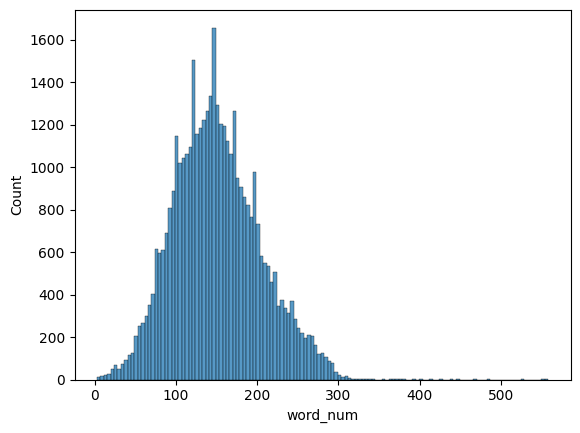

In [ ]:
sns.histplot(df_origin['word_num'])

<Axes: xlabel='sents_num', ylabel='Count'>

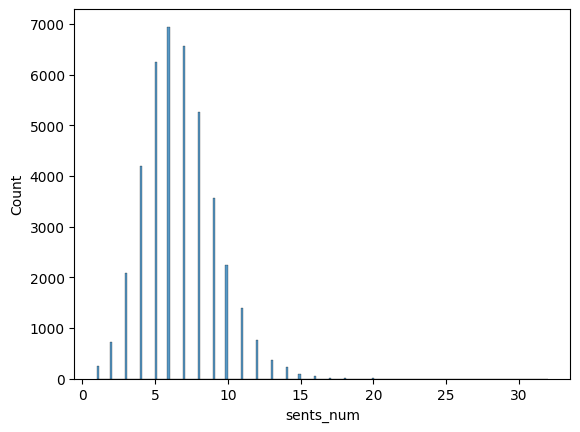

In [ ]:
sns.histplot(df_origin['sents_num'])

In [ ]:
df_origin.min()

origin_idx                                                        0
id                                                      0704.1020v1
title             "Attention" for Detecting Unreliable News in t...
abstract          "Background subtraction" is an old technique f...
abstract_clean    "Background subtraction" is an old technique f...
word_num                                                          3
sents_num                                                         1
dtype: object

In [ ]:
df_origin.max()

origin_idx                                                    40999
id                                               quant-ph/9907009v2
title             μ-MAR: Multiplane 3D Marker based Registration...
abstract          word2vec affords a simple yet powerful approac...
abstract_clean    word2vec affords a simple yet powerful approac...
word_num                                                        558
sents_num                                                        32
dtype: object

In [ ]:
df_origin[df_origin['sents_num'] == 1]

,origin_idx,id,title,abstract,abstract_clean,word_num,sents_num
144,144,1503.00036v2,Norm-Based Capacity Control in Neural Networks,"We investigate the capacity, convexity and cha...","We investigate the capacity, convexity and cha...",15,1
1411,1411,1701.05549v1,Deep Neural Networks - A Brief History,Introduction to deep neural networks and their...,Introduction to deep neural networks and their...,8,1
1674,1674,1712.05785v2,Sentiment Predictability for Stocks,"In this work, we present our findings and expe...","In this work, we present our findings and expe...",37,1
1887,1887,1803.07416v1,Tensor2Tensor for Neural Machine Translation,Tensor2Tensor is a library for deep learning m...,Tensor2Tensor is a library for deep learning m...,25,1
1969,1969,1703.03888v1,Segmentation of skin lesions based on fuzzy cl...,This paper proposes an innovative method for s...,This paper proposes an innovative method for s...,27,1
...,...,...,...,...,...,...,...
39514,39514,1607.07006v1,Autonomous Ingress of a UAV through a window u...,The use of autonomous UAVs for surveillance pu...,The use of autonomous UAVs for surveillance pu...,86,1
39761,39761,1703.09161v1,A Dynamic Programming Solution to Bounded Deji...,We propose a dynamic programming solution to i...,We propose a dynamic programming solution to i...,29,1
40360,40360,cs/0606100v4,The generating function of the polytope of tra...,This paper has been withdrawn by the author du...,This paper has been withdrawn by the author du...,19,1
40364,40364,cs/0611042v1,CSCR:Computer Supported Collaborative Research,It is suggested that a new area of CSCR (Compu...,It is suggested that a new area of CSCR (Compu...,34,1


In [ ]:
df_origin.loc[144]['abstract_clean']

'We investigate the capacity, convexity and characterization of a general family of norm-constrained feed-forward networks.'

In [ ]:
df_origin.loc[144]['word_num']

np.int64(15)

In [ ]:
df_clean = df_origin[(df_origin['word_num'] >= 50) & (df_origin['sents_num'] <= 12) & (df_origin['word_num'] <= 250)]
df_clean

,origin_idx,id,title,abstract,abstract_clean,word_num,sents_num
0,0,1802.00209v1,Dual Recurrent Attention Units for Visual Ques...,We propose an architecture for VQA which utili...,We propose an architecture for VQA which utili...,110,5
1,1,1603.03827v1,Sequential Short-Text Classification with Recu...,Recent approaches based on artificial neural n...,Recent approaches based on artificial neural n...,84,4
2,2,1606.00776v2,Multiresolution Recurrent Neural Networks: An ...,We introduce the multiresolution recurrent neu...,We introduce the multiresolution recurrent neu...,201,9
3,3,1705.08142v2,Learning what to share between loosely related...,Multi-task learning is motivated by the observ...,Multi-task learning is motivated by the observ...,174,8
4,4,1709.02349v2,A Deep Reinforcement Learning Chatbot,We present MILABOT: a deep reinforcement learn...,We present MILABOT: a deep reinforcement learn...,129,6
...,...,...,...,...,...,...,...
40994,40994,1404.3656v1,Methods for Ordinal Peer Grading,MOOCs have the potential to revolutionize high...,MOOCs have the potential to revolutionize high...,242,10
40996,40996,1404.5421v1,Concurrent bandits and cognitive radio networks,We consider the problem of multiple users targ...,We consider the problem of multiple users targ...,108,6
40997,40997,1404.5899v1,A Comparison of Clustering and Missing Data Me...,"In this paper, we compare and analyze clusteri...","In this paper, we compare and analyze clusteri...",105,4
40998,40998,1404.6369v1,Applying machine learning to the problem of ch...,Cylindrical algebraic decomposition(CAD) is a ...,Cylindrical algebraic decomposition(CAD) is a ...,97,5


<Axes: xlabel='word_num', ylabel='Count'>

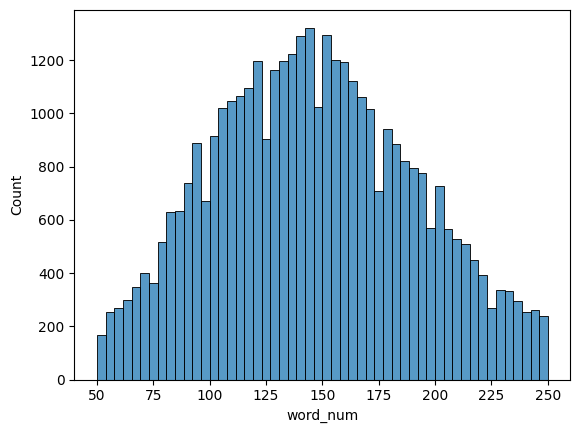

In [99]:
sns.histplot(df_clean['word_num'])

<Axes: xlabel='sents_num', ylabel='Count'>

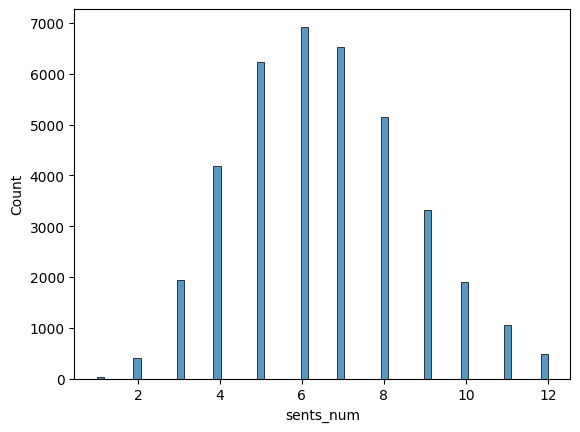

In [100]:
sns.histplot(df_clean['sents_num'])

In [101]:
df_clean.min()

origin_idx                                                        0
id                                                      0704.1028v1
title             "Attention" for Detecting Unreliable News in t...
abstract          "Background subtraction" is an old technique f...
abstract_clean    "Background subtraction" is an old technique f...
word_num                                                         50
sents_num                                                         1
dtype: object

In [ ]:
df_clean['title'] = df_origin['title'].fillna('').str.replace('\n', ' ', regex=False)
df_clean['title'] = df_origin['title'].fillna('').str.replace(r'\s+', ' ', regex=True)
df_clean['abstract_clean'] = df_origin['abstract_clean'].fillna('').str.replace(r'\s+', ' ', regex=False)

In [138]:
df_fin = df_clean[['origin_idx', 'id', 'title', 'abstract_clean']].copy()


In [139]:
df_fin.rename(columns={'id' : 'arxiv_id', 'abstract_clean' : 'abstract'}, inplace=True)

In [140]:
df_fin

,origin_idx,arxiv_id,title,abstract
0,0,1802.00209v1,Dual Recurrent Attention Units for Visual Ques...,We propose an architecture for VQA which utili...
1,1,1603.03827v1,Sequential Short-Text Classification with Recu...,Recent approaches based on artificial neural n...
2,2,1606.00776v2,Multiresolution Recurrent Neural Networks: An ...,We introduce the multiresolution recurrent neu...
3,3,1705.08142v2,Learning what to share between loosely related...,Multi-task learning is motivated by the observ...
4,4,1709.02349v2,A Deep Reinforcement Learning Chatbot,We present MILABOT: a deep reinforcement learn...
...,...,...,...,...
40994,40994,1404.3656v1,Methods for Ordinal Peer Grading,MOOCs have the potential to revolutionize high...
40996,40996,1404.5421v1,Concurrent bandits and cognitive radio networks,We consider the problem of multiple users targ...
40997,40997,1404.5899v1,A Comparison of Clustering and Missing Data Me...,"In this paper, we compare and analyze clusteri..."
40998,40998,1404.6369v1,Applying machine learning to the problem of ch...,Cylindrical algebraic decomposition(CAD) is a ...


In [141]:
df_fin.to_csv('../dataset/clean.tsv', sep='\t', index=False, encoding='utf-8-sig')

In [136]:
df_fin.loc[2]['abstract']

'We introduce the multiresolution recurrent neural network, which extends the sequence-to-sequence framework to model natural language generation as two parallel discrete stochastic processes: a sequence of high-level coarse tokens, and a sequence of natural language tokens. There are many ways to estimate or learn the high-level coarse tokens, but we argue that a simple extraction procedure is sufficient to capture a wealth of high-level discourse semantics. Such procedure allows training the multiresolution recurrent neural network by maximizing the exact joint log-likelihood over both sequences. In contrast to the standard log- likelihood objective w.r.t. natural language tokens (word perplexity), optimizing the joint log-likelihood biases the model towards modeling high-level abstractions. We apply the proposed model to the task of dialogue response generation in two challenging domains: the Ubuntu technical support domain, and Twitter conversations. On Ubuntu, the model outperform